# Unemployment as a Leading Indicator of Recession: A Cross-Country Perspective

**Countries:** United States, United Kingdom, Germany, France, Japan, Canada
**Data:** FRED (OECD-harmonised unemployment rate; real GDP, quarterly)
**Methodology:** Bivariate regression, sign regression, rolling regression, logit recession-probability model

This notebook contains the full analysis pipeline used in the accompanying report. It is organised into five stages: (1) data loading and cleaning, (2) bivariate and sign regressions, (3) rolling regression, (4) logit recession-probability model, (5) chart generation.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

DATA_DIR = "data"
FIG_DIR = "output/figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

## 1. Data loading and cleaning

Each country contributes two FRED series: the OECD-harmonised, seasonally adjusted unemployment rate (quarterly) and real GDP (quarterly level). Real GDP growth is computed as the quarter-on-quarter percentage change in the level series. The two series are merged on date for each country, then stacked into a single tidy panel.

In [ ]:
DATA_SOURCE_DIR = "data" 

FILES = {
    "United States": ("LRHUTTTTUSQ156S.csv", "GDPC1.csv"),
    "United Kingdom": ("LRHUTTTTGBQ156S.csv", "NGDPRSAXDCGBQ.csv"),
    "Germany": ("LRHUTTTTDEQ156S.csv", "CLVMNACSCAB1GQDE.csv"),
    "France": ("LRHUTTTTFRQ156S.csv", "CLVMNACSCAB1GQFR.csv"),
    "Japan": ("LRHUTTTTJPQ156S.csv", "JPNRGDPEXP__2_.csv"),
    "Canada": ("LRHUTTTTCAQ156S__1_.csv", "NGDPRSAXDCCAQ__1_.csv"),
}

def load_series(path):
    df = pd.read_csv(path)
    df.columns = ["date", "value"]
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna()

panels = []
summary_rows = []

for country, (unemp_file, gdp_file) in FILES.items():
    u = load_series(os.path.join(DATA_SOURCE_DIR, unemp_file)).rename(columns={"value": "unemployment_rate"})
    g = load_series(os.path.join(DATA_SOURCE_DIR, gdp_file)).sort_values("date").reset_index(drop=True)
    g["gdp_growth"] = g["value"].pct_change()
    g = g[["date", "gdp_growth"]]

    merged = pd.merge(u, g, on="date", how="inner").sort_values("date").reset_index(drop=True)
    merged["country"] = country
    merged = merged[["country", "date", "unemployment_rate", "gdp_growth"]]
    panels.append(merged)

    summary_rows.append({"country": country, "start": merged["date"].min().date(),
                          "end": merged["date"].max().date(), "n_obs": len(merged)})

panel = pd.concat(panels, ignore_index=True)
panel.to_csv(os.path.join(DATA_DIR, "panel.csv"), index=False)

coverage = pd.DataFrame(summary_rows)
coverage

,country,start,end,n_obs
0,United States,1955-01-01,2025-10-01,284
1,United Kingdom,1983-01-01,2026-01-01,173
2,Germany,1991-01-01,2026-04-01,142
3,France,1983-01-01,2026-04-01,174
4,Japan,1994-01-01,2026-04-01,130
5,Canada,1961-01-01,2026-01-01,261


## 2. Bivariate and sign regressions

Following the same structure as the reference yield-curve study, we regress GDP growth *k* quarters ahead on today's change in the unemployment rate (Δunemployment), for *k* = 1, 2 and 4 quarters. A parallel "sign regression" replaces the raw change with its sign, isolating the *direction* of the labour-market signal from its magnitude.

$$GDPGrowth_{t+k} = \beta_0 + \beta_1 \, \Delta Unemployment_t + \varepsilon_{t+k}$$

In [ ]:
countries = panel["country"].unique()
ks = [1, 2, 4]

def prep_country(df):
    df = df.sort_values("date").reset_index(drop=True)
    df["delta_unemp"] = df["unemployment_rate"].diff()
    df["sign_delta_unemp"] = np.sign(df["delta_unemp"])
    return df

bivariate_rows, sign_rows = [], []

for country in countries:
    df = prep_country(panel[panel["country"] == country])
    for k in ks:
        df[f"gdp_growth_fwd{k}"] = df["gdp_growth"].shift(-k)

        sub = df.dropna(subset=["delta_unemp", f"gdp_growth_fwd{k}"])
        X = sm.add_constant(sub["delta_unemp"]); y = sub[f"gdp_growth_fwd{k}"]
        model = sm.OLS(y, X).fit()
        bivariate_rows.append({"country": country, "k": k, "intercept": model.params["const"],
                                "coef": model.params["delta_unemp"], "coef_p": model.pvalues["delta_unemp"],
                                "r2": model.rsquared, "n": int(model.nobs)})

        sub2 = df.dropna(subset=["sign_delta_unemp", f"gdp_growth_fwd{k}"])
        X2 = sm.add_constant(sub2["sign_delta_unemp"]); y2 = sub2[f"gdp_growth_fwd{k}"]
        model2 = sm.OLS(y2, X2).fit()
        sign_rows.append({"country": country, "k": k, "intercept": model2.params["const"],
                           "coef": model2.params["sign_delta_unemp"], "coef_p": model2.pvalues["sign_delta_unemp"],
                           "r2": model2.rsquared, "n": int(model2.nobs)})

biv = pd.DataFrame(bivariate_rows); sgn = pd.DataFrame(sign_rows)
biv.to_csv(os.path.join(DATA_DIR, "bivariate_results.csv"), index=False)
sgn.to_csv(os.path.join(DATA_DIR, "sign_results.csv"), index=False)
biv[biv["k"] == 4]

,country,k,intercept,coef,coef_p,r2,n
2,United States,4,0.007410,0.001302,0.152568,0.007374,279
5,United Kingdom,4,0.005157,-0.002020,0.761993,0.000554,168
8,Germany,4,0.003021,0.006624,0.244049,0.010039,137
11,France,4,0.004371,0.006866,0.179139,0.010781,169
14,Japan,4,0.002071,0.015277,0.048045,0.031401,125
17,Canada,4,0.007282,-0.000465,0.718222,0.000513,256


## 3. Rolling regression

To examine whether the unemployment–GDP growth relationship is stable over time, we re-estimate the *k*=4 bivariate regression on rolling 10-year (40-quarter) windows, shifting one quarter at a time.

In [ ]:
WINDOW = 40
K = 4
rolling_rows = []

for country in countries:
    df = panel[panel["country"] == country].sort_values("date").reset_index(drop=True)
    df["delta_unemp"] = df["unemployment_rate"].diff()
    df["gdp_growth_fwd4"] = df["gdp_growth"].shift(-K)
    df = df.dropna(subset=["delta_unemp", "gdp_growth_fwd4"]).reset_index(drop=True)
    if len(df) < WINDOW + 5:
        continue
    for start in range(0, len(df) - WINDOW + 1):
        window = df.iloc[start:start + WINDOW]
        X = sm.add_constant(window["delta_unemp"]); y = window["gdp_growth_fwd4"]
        try:
            coef = sm.OLS(y, X).fit().params["delta_unemp"]
        except Exception:
            coef = np.nan
        rolling_rows.append({"country": country, "window_end": window["date"].iloc[-1], "coef": coef})

rolling_df = pd.DataFrame(rolling_rows)
rolling_df.to_csv(os.path.join(DATA_DIR, "rolling_results.csv"), index=False)
rolling_df.groupby("country")["coef"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
country,,,,
Canada,0.002544,0.005014,-0.005366,0.035472
France,0.005121,0.005598,-0.006341,0.022145
Germany,0.012461,0.011399,-0.004079,0.032327
Japan,0.015258,0.008714,0.002130,0.034712
United Kingdom,-0.000054,0.005745,-0.030609,0.007507
United States,0.000799,0.004304,-0.010009,0.015431


## 4. Logit recession-probability model

A technical recession is defined as two consecutive quarters of negative real GDP growth. We estimate a logit model of the probability of recession four quarters ahead, conditional on today's change in the unemployment rate:

$$P(Recession_{t+4}=1 \mid \Delta Unemployment_t) = \Lambda(\beta_0 + \beta_1 \, \Delta Unemployment_t)$$

In [ ]:
K = 4
logit_rows, prob_frames = [], []

for country in countries:
    df = panel[panel["country"] == country].sort_values("date").reset_index(drop=True)
    df["delta_unemp"] = df["unemployment_rate"].diff()
    df["neg_growth"] = df["gdp_growth"] < 0
    df["recession"] = (df["neg_growth"] & df["neg_growth"].shift(1)).astype(float)
    df.loc[df["neg_growth"].shift(1).isna(), "recession"] = np.nan
    df["recession_fwd4"] = df["recession"].shift(-K)

    sub = df.dropna(subset=["delta_unemp", "recession_fwd4"]).copy()
    X = sm.add_constant(sub["delta_unemp"]); y = sub["recession_fwd4"]
    model = sm.Logit(y, X).fit(disp=0)
    pred = model.predict(X)
    auc = roc_auc_score(y, pred) if y.nunique() > 1 else np.nan

    logit_rows.append({"country": country, "intercept": model.params["const"],
                        "coef": model.params["delta_unemp"], "coef_p": model.pvalues["delta_unemp"],
                        "pseudo_r2": model.prsquared, "auc": auc, "n": len(sub),
                        "n_recession_qtrs": int(sub["recession_fwd4"].sum())})

    sub["prob_recession"] = pred
    sub["country"] = country
    prob_frames.append(sub[["country", "date", "prob_recession", "recession_fwd4"]])

logit_df = pd.DataFrame(logit_rows)
logit_df.to_csv(os.path.join(DATA_DIR, "logit_results.csv"), index=False)
probs = pd.concat(prob_frames, ignore_index=True)
probs.to_csv(os.path.join(DATA_DIR, "logit_probabilities.csv"), index=False)
logit_df

,country,intercept,coef,coef_p,pseudo_r2,auc,n,n_recession_qtrs
0,United States,-3.195768,0.103865,0.753618,0.000886,0.635176,279,11
1,United Kingdom,-2.681827,1.667496,0.116620,0.028058,0.646786,168,11
2,Germany,-1.976873,-0.904599,0.486880,0.004760,0.569608,137,17
3,France,-3.744396,-4.358696,0.013148,0.118145,0.804703,169,6
4,Japan,-2.249863,-0.801836,0.722375,0.001646,0.498156,125,12
5,Canada,-2.776912,-0.022969,0.960188,0.000022,0.506501,256,15


## 5. Charts

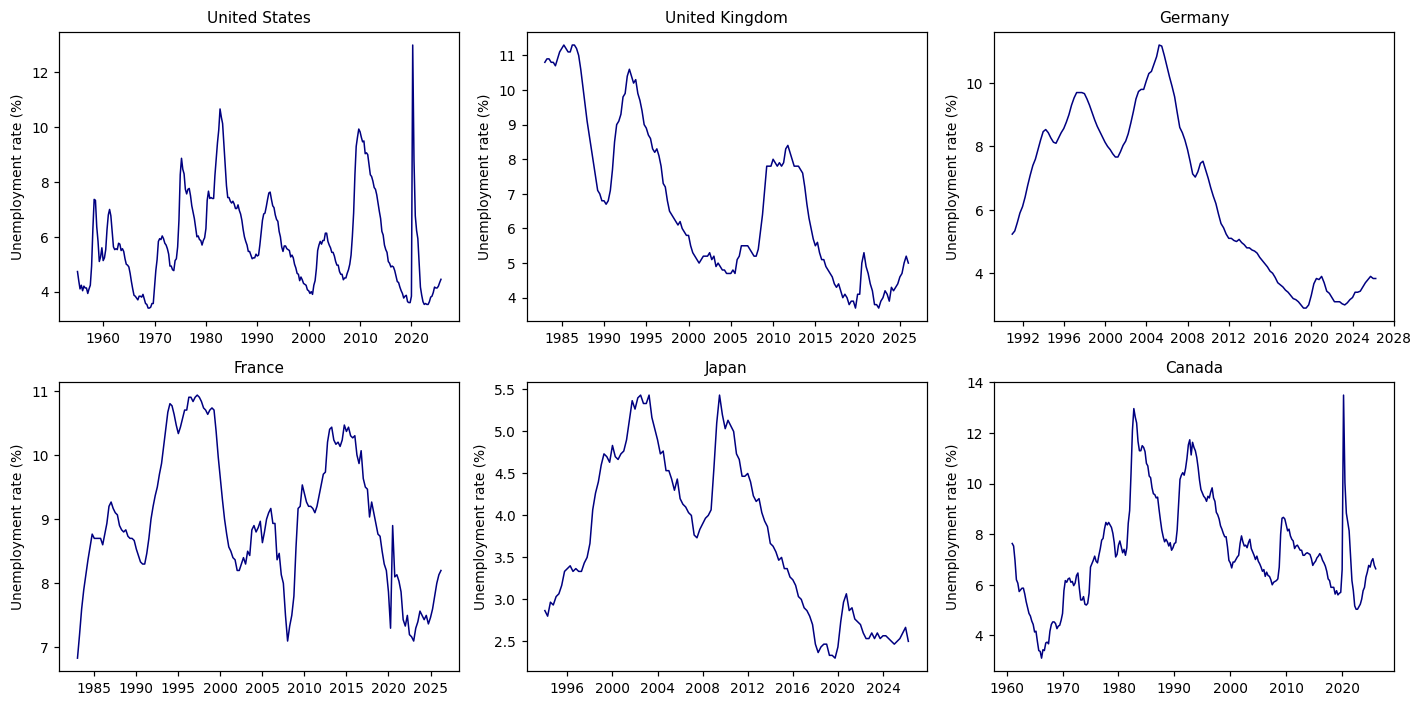

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, country in zip(axes.flat, countries):
    d = panel[panel["country"] == country]
    ax.plot(d["date"], d["unemployment_rate"], color="navy", linewidth=1)
    ax.set_title(country, fontsize=10); ax.set_ylabel("Unemployment rate (%)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig1_unemployment_series.png"))
plt.show()

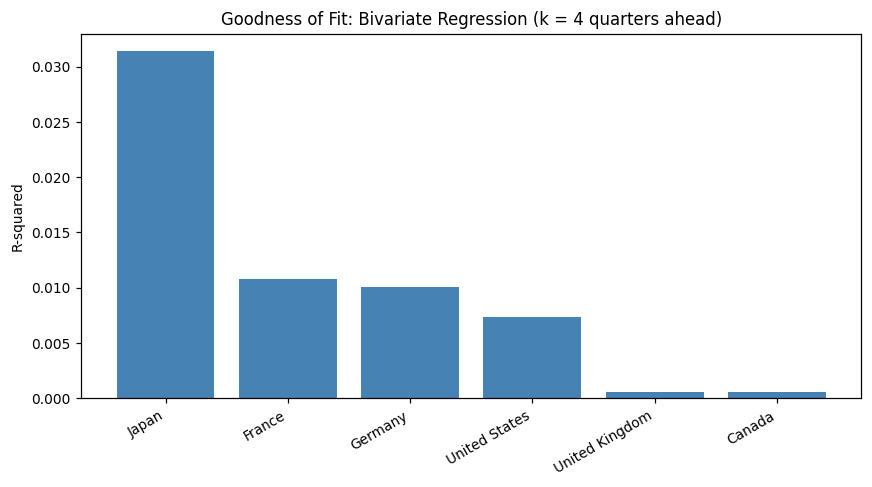

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sub = biv[biv["k"] == 4].sort_values("r2", ascending=False)
ax.bar(sub["country"], sub["r2"], color="steelblue")
ax.set_ylabel("R-squared"); ax.set_title("Goodness of Fit: Bivariate Regression (k = 4 quarters ahead)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig2_r2_bivariate.png"))
plt.show()

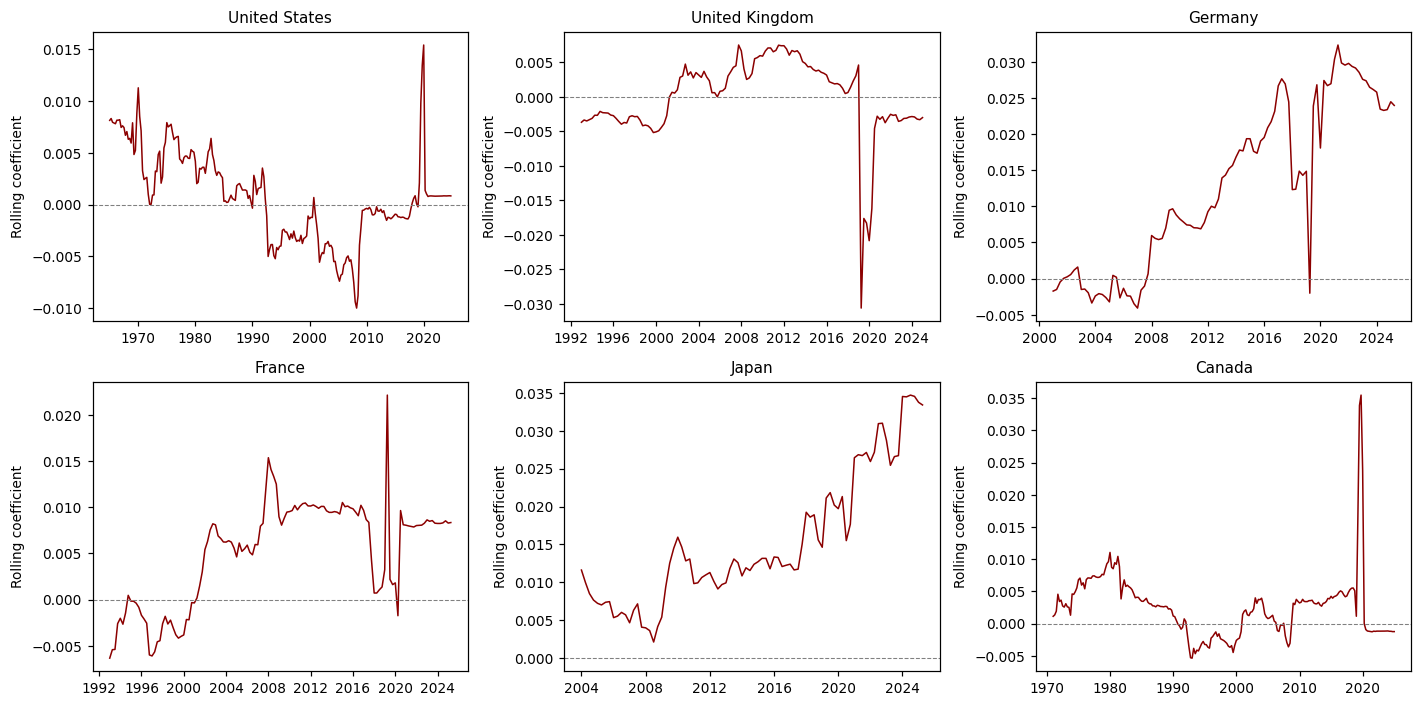

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, country in zip(axes.flat, countries):
    d = rolling_df[rolling_df["country"] == country]
    ax.plot(d["window_end"], d["coef"], color="darkred", linewidth=1)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
    ax.set_title(country, fontsize=10); ax.set_ylabel("Rolling coefficient")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig3_rolling_coef.png"))
plt.show()

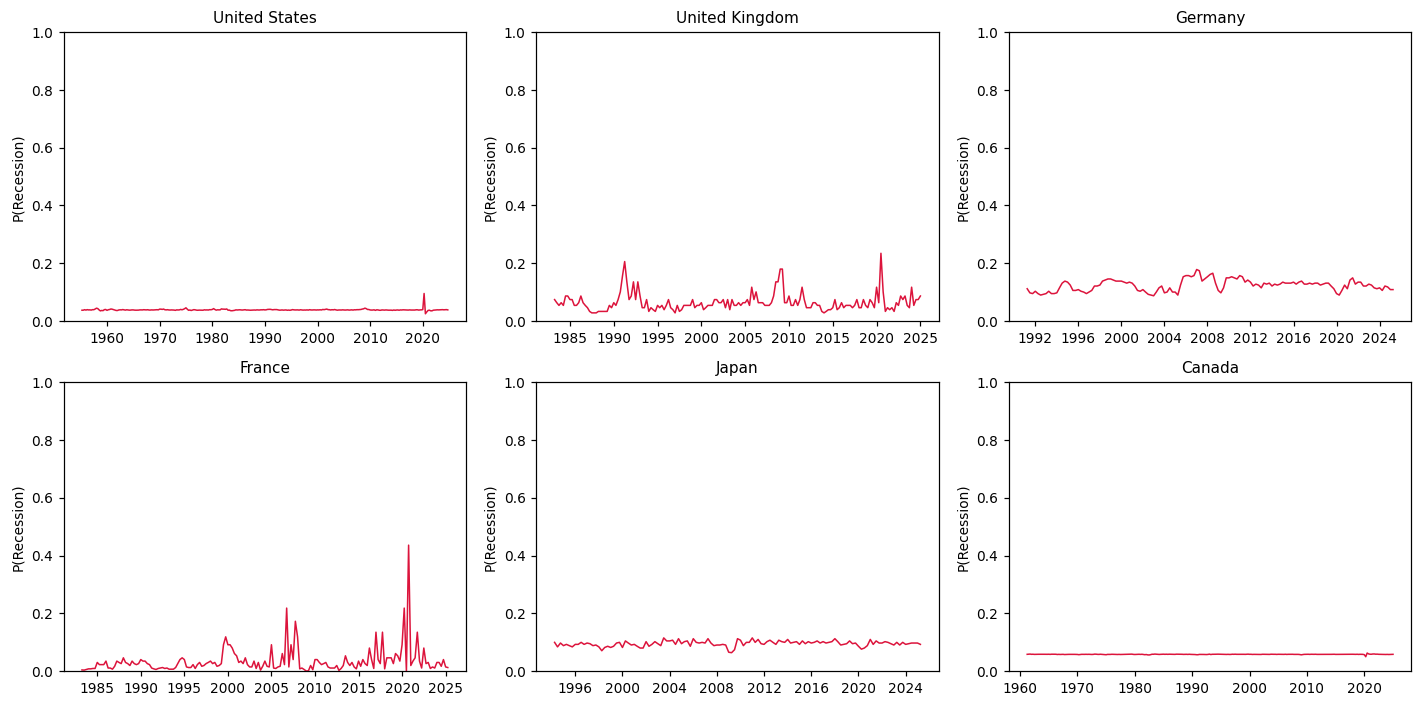

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, country in zip(axes.flat, countries):
    d = probs[probs["country"] == country]
    ax.plot(d["date"], d["prob_recession"], color="crimson", linewidth=1)
    ax.set_ylim(0, 1); ax.set_title(country, fontsize=10); ax.set_ylabel("P(Recession)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig4_recession_probability.png"))
plt.show()

## 6. Pseudo-out-of-sample evaluation

To assess whether the logit model would have been useful in real time, the final 24 quarters of each country's sample are held out. The model is estimated on the earlier ("estimation") sample only, then used to forecast recession probability over the holdout window. Forecast accuracy is measured by mean squared forecast error (MSFE) and compared against a naive benchmark that always predicts the estimation sample's unconditional recession frequency. A relative MSFE below 1 means the model beats the naive benchmark out-of-sample.

In [ ]:
HOLDOUT = 24
oos_rows, oos_frames = [], []

for country in countries:
    df = panel[panel["country"] == country].sort_values("date").reset_index(drop=True)
    df["delta_unemp"] = df["unemployment_rate"].diff()
    df["neg_growth"] = df["gdp_growth"] < 0
    df["recession"] = (df["neg_growth"] & df["neg_growth"].shift(1)).astype(float)
    df.loc[df["neg_growth"].shift(1).isna(), "recession"] = np.nan
    df["recession_fwd4"] = df["recession"].shift(-K)
    df = df.dropna(subset=["delta_unemp", "recession_fwd4"]).reset_index(drop=True)

    est, oos = df.iloc[:-HOLDOUT], df.iloc[-HOLDOUT:]
    X_est = sm.add_constant(est["delta_unemp"]); y_est = est["recession_fwd4"]
    model = sm.Logit(y_est, X_est).fit(disp=0)
    X_oos = sm.add_constant(oos["delta_unemp"], has_constant="add")
    pred = model.predict(X_oos)

    msfe_model = float(((oos["recession_fwd4"] - pred) ** 2).mean())
    p_naive = y_est.mean()
    msfe_naive = float(((oos["recession_fwd4"] - p_naive) ** 2).mean())

    oos_rows.append({"country": country, "estimation_n": len(est), "holdout_n": len(oos),
                      "oos_recession_qtrs": int(oos["recession_fwd4"].sum()),
                      "msfe_model": msfe_model, "msfe_naive": msfe_naive,
                      "relative_msfe": msfe_model / msfe_naive if msfe_naive > 0 else np.nan})

    tmp = oos[["date", "recession_fwd4"]].copy(); tmp["pred"] = pred.values; tmp["country"] = country
    oos_frames.append(tmp)

oos_res = pd.DataFrame(oos_rows)
oos_res.to_csv(os.path.join(DATA_DIR, "oos_results.csv"), index=False)
oos_pred = pd.concat(oos_frames, ignore_index=True)
oos_pred.to_csv(os.path.join(DATA_DIR, "oos_predictions.csv"), index=False)
oos_res

,country,estimation_n,holdout_n,oos_recession_qtrs,msfe_model,msfe_naive,relative_msfe
0,United States,255,24,1,0.078532,0.039937,1.966422
1,United Kingdom,144,24,2,0.077145,0.076823,1.004198
2,Germany,113,24,3,0.108345,0.109376,0.990568
3,France,145,24,0,0.037857,0.001712,22.109736
4,Japan,101,24,1,0.044191,0.044452,0.994124
5,Canada,232,24,2,0.077594,0.077134,1.005958


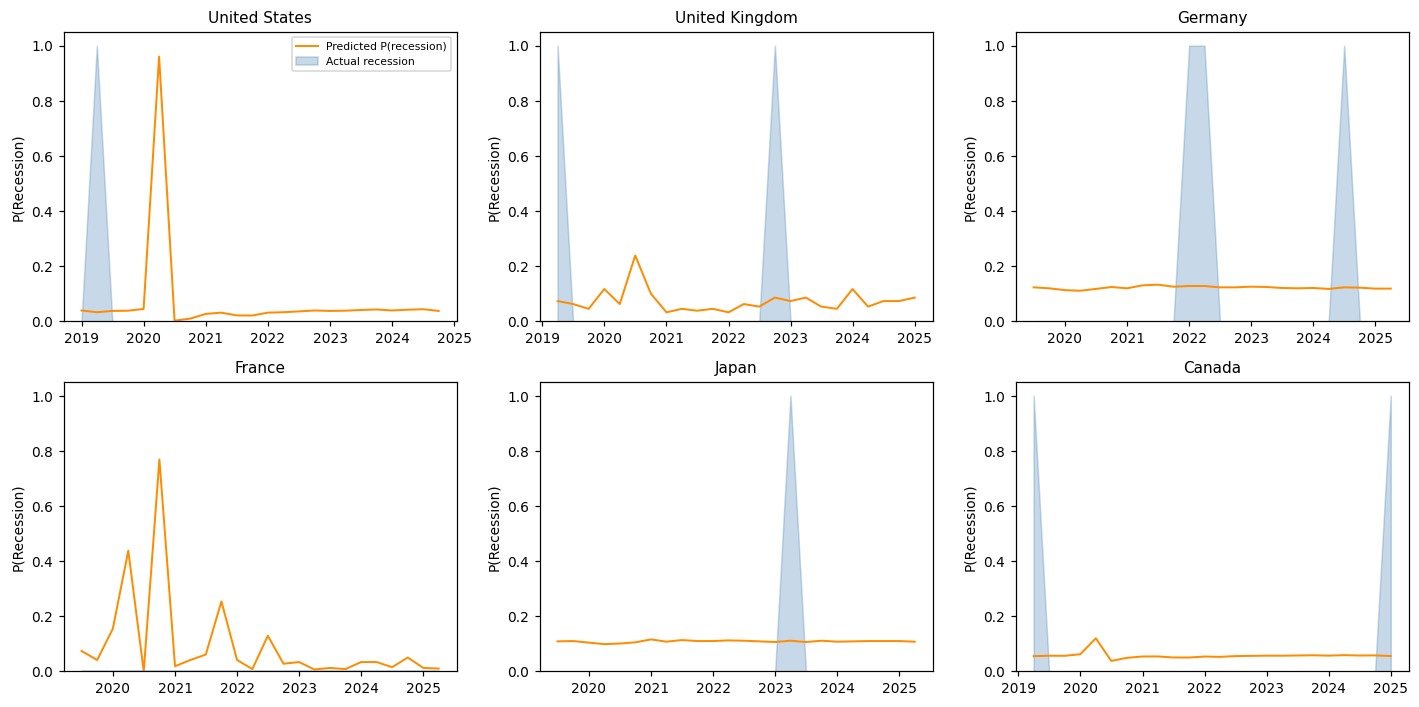

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, country in zip(axes.flat, countries):
    d = oos_pred[oos_pred["country"] == country]
    ax.plot(d["date"], d["pred"], color="darkorange", linewidth=1.3, label="Predicted P(recession)")
    ax.fill_between(d["date"], 0, d["recession_fwd4"], color="steelblue", alpha=0.3, label="Actual recession")
    ax.set_ylim(0, 1.05); ax.set_title(country, fontsize=10); ax.set_ylabel("P(Recession)")
axes.flat[0].legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig5_oos_prediction.png"))
plt.show()

## Summary

- **Bivariate & sign regressions:** coefficients are generally small and statistically insignificant across most countries, echoing the reference study's finding that magnitude-based signals are weak and unstable across borders.
- **Rolling regression:** the unemployment–growth relationship is not stable through time; coefficients drift and occasionally flip sign, most visibly around the 2008 financial crisis and 2020 pandemic shock.
- **Logit model:** in-sample performance is uneven with France showing the strongest (if counter-intuitively signed) statistical relationship, while the US and Japan show weak, insignificant relationships.
- **Pseudo-out-of-sample:** the logit model fails to convincingly beat a naive constant-probability benchmark in any country over the 2019–2025 holdout, and the in-sample "best" performer (France) deteriorates most severely out-of-sample which is a classic overfitting pattern, consistent with Estrella and Mishkin's (1998) warning that in-sample fit is a poor guide to real-time recession forecasting performance.